In [1]:
!pip install -q lightgbm pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Imports OK — pandas', pd.__version__, '| lightgbm', lgb.__version__)

Imports OK — pandas 2.2.2 | lightgbm 4.6.0


In [3]:
from pathlib import Path

# List each file explicitly. Adjust paths if you put them somewhere else.
files = [
    Path('/content/sample_data/Southern_Water_Domestic_Drinking_Water_Quality_2016_2018_part1.csv'),
    Path('/content/sample_data/Southern_Water_Drinking_Water_Quality_2018_2022_part1.csv'),
    Path('/content/sample_data/Southern_Water_Drinking_Water_Quality_2022_2026_part1.csv'),
    Path('/content/sample_data/Southern_Water_Domestic__Drinking_Water_Quality_2022_2026_part2.csv'),
]

# Check each one exists before going any further
for f in files:
    assert f.exists(), f'Missing file: {f}'
    print(f'  ✓ {f.name}')

print(f'\nAll {len(files)} files ready.')

  ✓ Southern_Water_Domestic_Drinking_Water_Quality_2016_2018_part1.csv
  ✓ Southern_Water_Drinking_Water_Quality_2018_2022_part1.csv
  ✓ Southern_Water_Drinking_Water_Quality_2022_2026_part1.csv
  ✓ Southern_Water_Domestic__Drinking_Water_Quality_2022_2026_part2.csv

All 4 files ready.


In [5]:
dfs = []
for f in files:
    df = pd.read_csv(f, encoding='utf-8-sig')   # utf-8-sig strips the BOM in file 1
    print(f'  {f.name}: {len(df):,} rows')
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)
del dfs

raw['Sample_Date'] = pd.to_datetime(raw['Sample_Date'], format='%Y/%m/%d', errors='coerce')
raw['Result']      = pd.to_numeric(raw['Result'], errors='coerce')
raw['Censor_Flag'] = (raw['Units'].fillna('')
                                  .replace({'<': 'below_lod', '>': 'above_lod', '': 'none'}))
raw = raw.drop(columns=['Units', 'Operator', 'ObjectId'])
raw = raw.dropna(subset=['Sample_Date', 'Result'])

print(f'\nCombined: {len(raw):,} rows')
print(f'Date range: {raw.Sample_Date.min().date()} → {raw.Sample_Date.max().date()}')
print(f'Unique determinands: {raw.Determinand.nunique()}')
print(f'Unique LSOAs: {raw.LSOA.nunique()}')

  Southern_Water_Domestic_Drinking_Water_Quality_2016_2018_part1.csv: 299,467 rows
  Southern_Water_Drinking_Water_Quality_2018_2022_part1.csv: 519,161 rows
  Southern_Water_Drinking_Water_Quality_2022_2026_part1.csv: 1,000,000 rows
  Southern_Water_Domestic__Drinking_Water_Quality_2022_2026_part2.csv: 313,798 rows

Combined: 2,132,425 rows
Date range: 2016-01-04 → 2026-04-30
Unique determinands: 422
Unique LSOAs: 1566


Free chlorine samples: 133,242


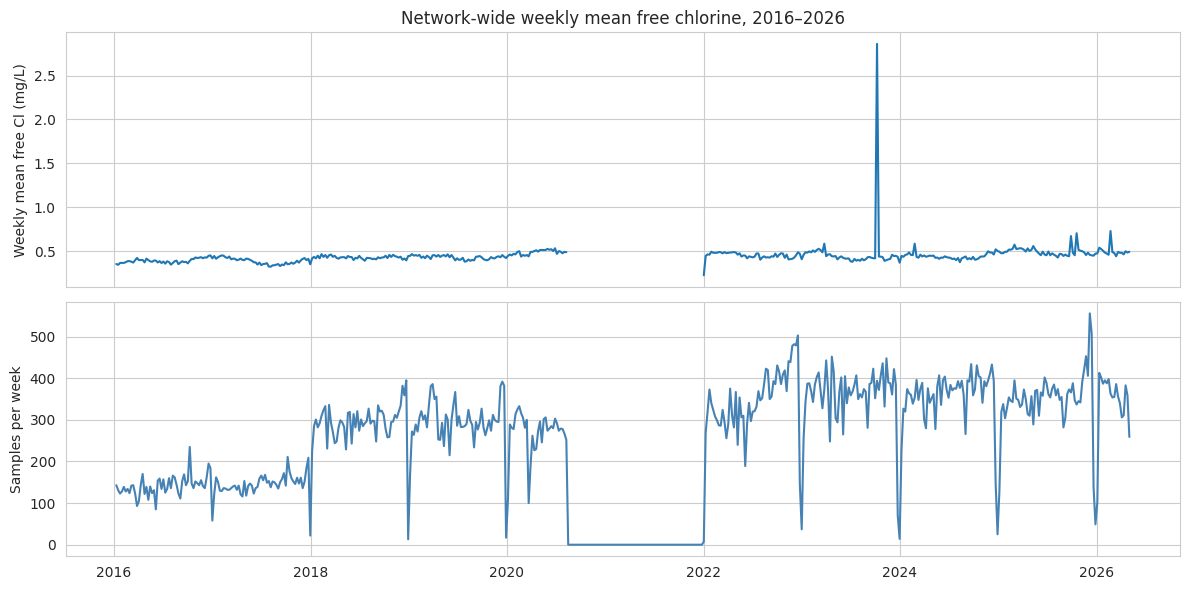


Per-LSOA sample counts: median 77, max 418, min 3
LSOAs with ≥ 50 chlorine samples: 1332


In [6]:
TARGET_DET = 'CHLORINE (FREE)'
chl = raw[raw.Determinand == TARGET_DET].copy()
print(f'Free chlorine samples: {len(chl):,}')

weekly_net = chl.set_index('Sample_Date').resample('W')['Result'].agg(['mean', 'count'])
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(weekly_net.index, weekly_net['mean'])
ax[0].set_ylabel('Weekly mean free Cl (mg/L)')
ax[0].set_title('Network-wide weekly mean free chlorine, 2016–2026')
ax[1].plot(weekly_net.index, weekly_net['count'], color='steelblue')
ax[1].set_ylabel('Samples per week')
plt.tight_layout(); plt.show()

per_lsoa = chl.groupby('LSOA').size().sort_values(ascending=False)
print(f'\nPer-LSOA sample counts: median {per_lsoa.median():.0f}, max {per_lsoa.max()}, min {per_lsoa.min()}')
print(f'LSOAs with ≥ 50 chlorine samples: {(per_lsoa >= 50).sum()}')

In [7]:
MIN_SAMPLES_PER_LSOA = 50
good_lsoas = per_lsoa[per_lsoa >= MIN_SAMPLES_PER_LSOA].index
print(f'Keeping {len(good_lsoas)} LSOAs')

def weekly_lsoa(df, det):
    sub = df[df.Determinand == det].copy()
    sub['week'] = sub['Sample_Date'].dt.to_period('W').dt.start_time
    return (sub.groupby(['LSOA', 'week'])['Result']
               .mean().reset_index().rename(columns={'Result': det}))

raw_kept = raw[raw.LSOA.isin(good_lsoas)]
panel = weekly_lsoa(raw_kept, 'CHLORINE (FREE)').rename(columns={'CHLORINE (FREE)': 'free_cl'})

for det, col in [('TEMPERATURE', 'temp'),
                 ('TURBIDITY',   'turb'),
                 ('CHLORINE (TOTAL)', 'total_cl'),
                 ('PH',          'ph')]:
    cov = weekly_lsoa(raw_kept, det).rename(columns={det: col})
    panel = panel.merge(cov, on=['LSOA', 'week'], how='left')

panel = panel.sort_values(['LSOA', 'week']).reset_index(drop=True)

for lag in [1, 2, 4, 8]:
    panel[f'free_cl_lag{lag}'] = panel.groupby('LSOA')['free_cl'].shift(lag)

panel['free_cl_roll4_mean'] = (
    panel.groupby('LSOA')['free_cl']
         .transform(lambda s: s.shift(1).rolling(4, min_periods=2).mean()))
panel['free_cl_roll4_std'] = (
    panel.groupby('LSOA')['free_cl']
         .transform(lambda s: s.shift(1).rolling(4, min_periods=2).std()))

panel['month'] = panel['week'].dt.month
panel['woy']   = panel['week'].dt.isocalendar().week.astype(int)
panel['year']  = panel['week'].dt.year

le = LabelEncoder()
panel['lsoa_id'] = le.fit_transform(panel['LSOA'])

panel_model = panel.dropna(subset=['free_cl_lag1', 'free_cl_lag2'])
print(f'Modelling table: {len(panel_model):,} rows | {panel_model.LSOA.nunique()} LSOAs')
panel_model.head()

Keeping 1332 LSOAs
Modelling table: 57,679 rows | 1332 LSOAs


,LSOA,week,free_cl,temp,turb,total_cl,ph,free_cl_lag1,free_cl_lag2,free_cl_lag4,free_cl_lag8,free_cl_roll4_mean,free_cl_roll4_std,month,woy,year,lsoa_id
2,E01016016,2016-03-28,0.48,10.0,NaN,0.50,NaN,0.33,0.52,NaN,NaN,0.425000,0.134350,3,13,2016,0
3,E01016016,2016-08-01,0.34,17.4,NaN,0.45,NaN,0.48,0.33,NaN,NaN,0.443333,0.100167,8,31,2016,0
4,E01016016,2017-05-08,0.57,13.2,0.05,0.60,NaN,0.34,0.48,0.52,NaN,0.417500,0.096738,5,19,2017,0
5,E01016016,2017-07-17,0.05,23.4,NaN,0.16,NaN,0.57,0.34,0.33,NaN,0.430000,0.115758,7,29,2017,0
6,E01016016,2017-09-18,0.32,19.1,0.15,0.37,NaN,0.05,0.57,0.48,NaN,0.360000,0.227303,9,38,2017,0


In [13]:
print(f'panel rows: {len(panel):,}')
print(f'panel LSOAs: {panel.LSOA.nunique()}')
print('\nNon-null counts per column:')
print(panel.notna().sum())
print(f'\npanel_model rows after dropna: {len(panel_model):,}')

panel rows: 60,343
panel LSOAs: 1332

Non-null counts per column:
LSOA                  60343
week                  60343
free_cl               60343
temp                  57495
turb                  27396
total_cl              60325
ph                    27376
free_cl_lag1          59011
free_cl_lag2          57679
free_cl_lag4          55015
free_cl_lag8          49687
free_cl_roll4_mean    57679
free_cl_roll4_std     57679
month                 60343
woy                   60343
year                  60343
lsoa_id               60343
dtype: int64

panel_model rows after dropna: 57,679


In [22]:
SPLIT_DATE = '2025-01-01'
train = panel_model[panel_model.week <  SPLIT_DATE]
test  = panel_model[panel_model.week >= SPLIT_DATE]
print(f'Train: {len(train):,} rows | Test: {len(test):,} rows')

feature_cols = ['lsoa_id', 'temp', 'turb', 'ph',
                   'free_cl_lag1', 'free_cl_lag2', 'free_cl_lag4', 'free_cl_lag8',
                   'free_cl_roll4_mean', 'free_cl_roll4_std',
                   'month', 'woy', 'year']
TARGET = 'free_cl'

X_train, y_train = train[feature_cols], train[TARGET]
X_test,  y_test  = test[feature_cols],  test[TARGET]

model = lgb.LGBMRegressor(
    n_estimators=800, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8, random_state=42,
)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    categorical_feature=['lsoa_id'],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

Train: 47,645 rows | Test: 10,034 rows
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005402 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3618
[LightGBM] [Info] Number of data points in the train set: 47645, number of used features: 13
[LightGBM] [Info] Start training from score 0.439989
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[16]	valid_0's l2: 0.301287


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=800,
              num_leaves=63, random_state=42, subsample=0.8)

In [23]:
print(f'panel_model: {len(panel_model):,}')
print(f'train: {len(train):,}')
print(f'test: {len(test):,}')
print(f'X_train shape: {X_train.shape}')

panel_model: 57,679
train: 47,645
test: 10,034
X_train shape: (47645, 13)


LightGBM    MAE: 0.145  RMSE: 0.549  mg/L
Persistence MAE: 0.147  RMSE: 0.748  mg/L

LightGBM beats baseline by 26.6% on RMSE


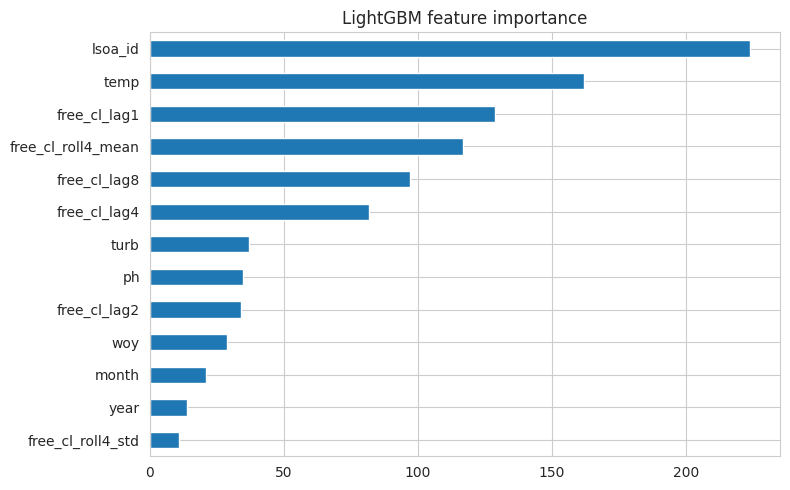

In [24]:
preds = model.predict(X_test)
mae   = mean_absolute_error(y_test, preds)
rmse  = np.sqrt(mean_squared_error(y_test, preds))
print(f'LightGBM    MAE: {mae:.3f}  RMSE: {rmse:.3f}  mg/L')

baseline_pred = X_test['free_cl_lag1']
b_mae  = mean_absolute_error(y_test, baseline_pred)
b_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f'Persistence MAE: {b_mae:.3f}  RMSE: {b_rmse:.3f}  mg/L')
print(f'\nLightGBM beats baseline by {(b_rmse - rmse) / b_rmse * 100:.1f}% on RMSE')

fi = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
fi.plot.barh(figsize=(8, 5), title='LightGBM feature importance')
plt.tight_layout(); plt.show()

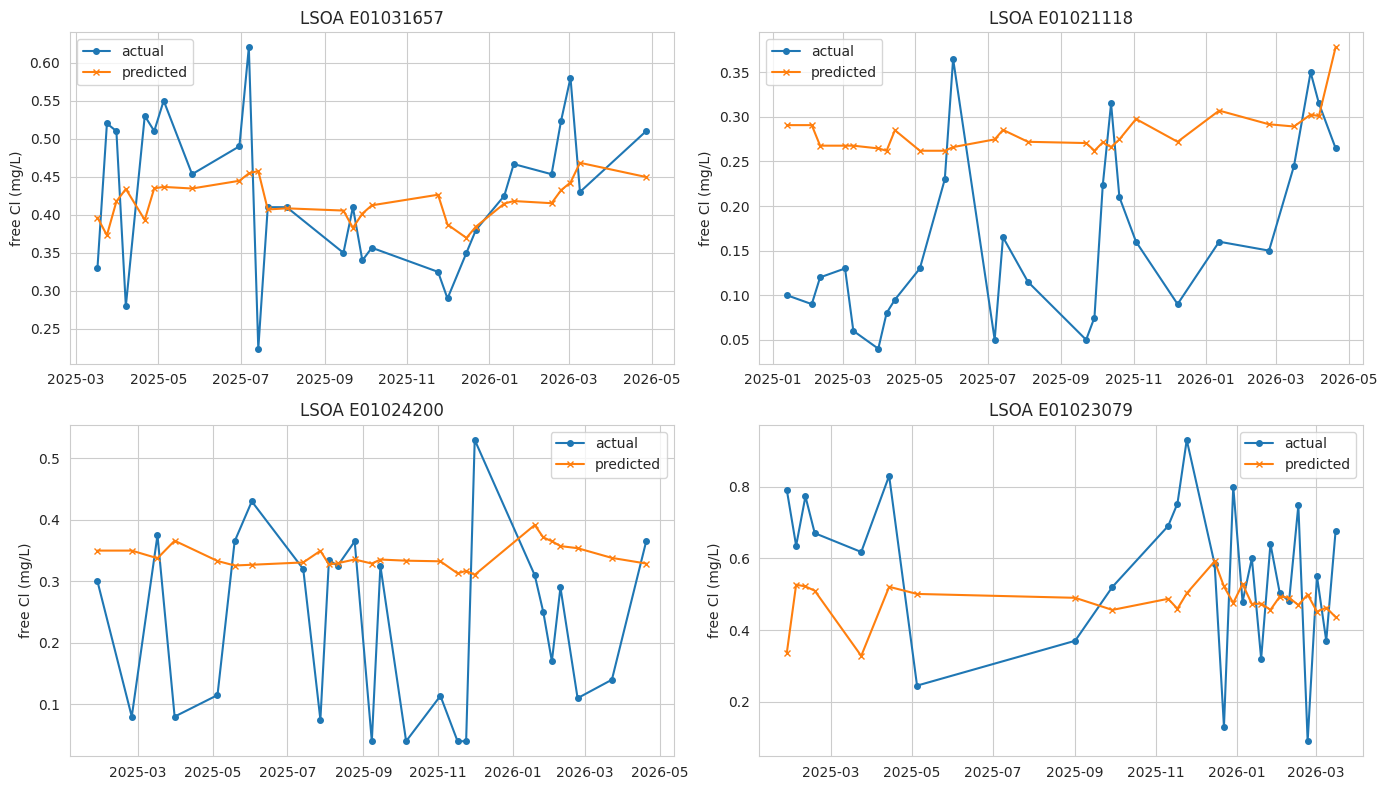

In [25]:
results = test.copy()
results['pred'] = preds

sample_lsoas = (results.groupby('LSOA').size()
                       .sort_values(ascending=False)
                       .head(4).index)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, lsoa in zip(axes.flatten(), sample_lsoas):
    sub = results[results.LSOA == lsoa].sort_values('week')
    ax.plot(sub.week, sub.free_cl, label='actual',    marker='o', ms=4)
    ax.plot(sub.week, sub.pred,    label='predicted', marker='x', ms=4)
    ax.set_title(f'LSOA {lsoa}')
    ax.set_ylabel('free Cl (mg/L)')
    ax.legend()
plt.tight_layout(); plt.show()

In [26]:
results['residual'] = results['free_cl'] - results['pred']
sigma = results['residual'].std()
results['z'] = results['residual'] / sigma
results['anomaly'] = results['z'].abs() > 3

n_anom = results['anomaly'].sum()
print(f'Flagged {n_anom} anomalies ({n_anom/len(results)*100:.2f}%) at |z| > 3')

print('\nTop 10 largest positive residuals (chlorine higher than expected):')
print(results.nlargest(10, 'residual')[['LSOA','week','free_cl','pred','residual']].to_string(index=False))

print('\nTop 10 largest negative residuals (chlorine lower than expected — operational risk):')
print(results.nsmallest(10, 'residual')[['LSOA','week','free_cl','pred','residual']].to_string(index=False))

Flagged 5 anomalies (0.05%) at |z| > 3

Top 10 largest positive residuals (chlorine higher than expected):
     LSOA       week  free_cl     pred  residual
E01023256 2025-10-13  41.3400 0.488054 40.851946
E01016938 2025-09-22  31.8800 0.516554 31.363446
E01021032 2026-02-23   3.0600 0.422966  2.637034
E01021110 2025-04-21   1.6100 0.275941  1.334059
E01022675 2025-10-27   1.4100 0.492139  0.917861
E01023229 2025-02-24   1.2875 0.447865  0.839635
E01022674 2025-12-01   1.3200 0.481040  0.838960
E01022674 2025-11-03   1.2900 0.462634  0.827366
E01022674 2025-10-20   1.3300 0.509815  0.820185
E01035447 2025-02-24   1.2450 0.459730  0.785270

Top 10 largest negative residuals (chlorine lower than expected — operational risk):
     LSOA       week  free_cl     pred  residual
E01024264 2025-12-08 0.585000 2.847885 -2.262885
E01024264 2025-12-01 0.700000 2.851764 -2.151764
E01016858 2025-01-27 0.820000 2.242901 -1.422901
E01024264 2025-05-12 0.550000 1.949747 -1.399747
E01023229 2025-02-03 0.

In [27]:
# ===== CELL 11: Generate the numbers for the LinkedIn post =====

print('=' * 65)
print('  NUMBERS FOR THE LINKEDIN POST')
print('=' * 65)

# --- Dataset description (opening line) ---
print('\n--- DATASET ---')
print(f'Total sample records:  {len(raw):,}')
print(f'Unique determinands:   {raw.Determinand.nunique()}')
print(f'Unique LSOAs:          {raw.LSOA.nunique()}')
print(f'Date range:            {raw.Sample_Date.min().date()} to {raw.Sample_Date.max().date()}')
free_cl_n = (raw.Determinand == 'CHLORINE (FREE)').sum()
print(f'Free chlorine samples: {free_cl_n:,}')

# --- Censoring rate (for the "<LOD" claim in the post) ---
print('\n--- CENSORING ---')
censor_rate = (raw.Censor_Flag == 'below_lod').mean()
print(f'Below detection limit overall: {censor_rate*100:.1f}% of all readings')
cl_censor = (raw[raw.Determinand == 'CHLORINE (FREE)'].Censor_Flag == 'below_lod').mean()
print(f'Below LOD just for free Cl:    {cl_censor*100:.1f}%')

# --- Model performance ---
print('\n--- MODEL PERFORMANCE ON HELD-OUT 2025-26 ---')
mae   = mean_absolute_error(y_test, preds)
rmse  = np.sqrt(mean_squared_error(y_test, preds))
b_mae  = mean_absolute_error(y_test, X_test['free_cl_lag1'])
b_rmse = np.sqrt(mean_squared_error(y_test, X_test['free_cl_lag1']))
rmse_improvement = (b_rmse - rmse) / b_rmse * 100
mae_improvement  = (b_mae - mae)  / b_mae  * 100

print(f'LightGBM    MAE:  {mae:.3f} mg/L  |  RMSE: {rmse:.3f} mg/L')
print(f'Persistence MAE:  {b_mae:.3f} mg/L  |  RMSE: {b_rmse:.3f} mg/L')
print(f'RMSE improvement: {rmse_improvement:.1f}%')
print(f'MAE  improvement: {mae_improvement:.1f}%')

# --- Feature importance ranking (to verify the "temperature ranks second" claim) ---
print('\n--- FEATURE IMPORTANCE RANKING (verify your post matches this!) ---')
fi = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
for i, (feat, imp) in enumerate(fi.items(), 1):
    print(f'  {i:2}. {feat:25} {imp:6}')

# --- Anomaly count ---
print('\n--- ANOMALIES ---')
print(f'Total test predictions:    {len(results):,}')
print(f'Anomalies flagged (|z|>3): {results.anomaly.sum():,}')
print(f'Anomaly rate:              {results.anomaly.mean()*100:.2f}%')

# --- LinkedIn-ready snippet ---
print('\n' + '=' * 65)
print('  COPY-PASTE SUMMARY FOR THE POST')
print('=' * 65)
print(f"""
DATASET
  ~{len(raw)/1e6:.1f}M sample records | {raw.Determinand.nunique()} determinands | {raw.LSOA.nunique():,} LSOAs
  Free Cl samples: ~{free_cl_n/1000:.0f}k
  Censoring (<LOD): {censor_rate*100:.0f}% of all readings  ({cl_censor*100:.0f}% for free Cl)

HELD-OUT 2025-26 TEST
  Test MAE:  {mae:.3f} mg/L
  Test RMSE: {rmse:.3f} mg/L
  RMSE improvement over persistence baseline: {rmse_improvement:.1f}%

TOP 5 FEATURE IMPORTANCES
  1. {fi.index[0]}
  2. {fi.index[1]}
  3. {fi.index[2]}
  4. {fi.index[3]}
  5. {fi.index[4]}

ANOMALIES
  Flagged in test window (|z|>3): {results.anomaly.sum():,} out of {len(results):,} predictions
""")

  NUMBERS FOR THE LINKEDIN POST

--- DATASET ---
Total sample records:  2,132,425
Unique determinands:   422
Unique LSOAs:          1566
Date range:            2016-01-04 to 2026-04-30
Free chlorine samples: 133,242

--- CENSORING ---
Below detection limit overall: 13.4% of all readings
Below LOD just for free Cl:    1.2%

--- MODEL PERFORMANCE ON HELD-OUT 2025-26 ---
LightGBM    MAE:  0.145 mg/L  |  RMSE: 0.549 mg/L
Persistence MAE:  0.147 mg/L  |  RMSE: 0.748 mg/L
RMSE improvement: 26.6%
MAE  improvement: 1.4%

--- FEATURE IMPORTANCE RANKING (verify your post matches this!) ---
   1. lsoa_id                      224
   2. temp                         162
   3. free_cl_lag1                 129
   4. free_cl_roll4_mean           117
   5. free_cl_lag8                  97
   6. free_cl_lag4                  82
   7. turb                          37
   8. ph                            35
   9. free_cl_lag2                  34
  10. woy                           29
  11. month            

In [28]:
print('Current feature_cols:')
print(feature_cols)
print(f'\nNumber of features: {len(feature_cols)}')
print(f'Is total_cl in the list? {"total_cl" in feature_cols}')

Current feature_cols:
['lsoa_id', 'temp', 'turb', 'ph', 'free_cl_lag1', 'free_cl_lag2', 'free_cl_lag4', 'free_cl_lag8', 'free_cl_roll4_mean', 'free_cl_roll4_std', 'month', 'woy', 'year']

Number of features: 13
Is total_cl in the list? False
